# Exploração — safra por UF e mês (SIDRA/LSPA 6588)

Objetivo: entender a estrutura das **features de oferta agrícola** — o que é uma linha, por que
existem tantos nulos, e como a coluna `revisao_pct_prod` (o sinal de choque de oferta) realmente se
comporta.

Fonte: `data/interim/parquet/safra_uf_mes.parquet`, produzido por
[03_sidra_lspa.py](../src/coleta/T-012_T-013/03_sidra_lspa.py) — ticket
[T-012](../tickets/01-coleta/T-012-sidra-lspa.md).

## A pergunta que este notebook responde

> *Cada linha é a produção daquele mês?*

**Não** — e essa é a armadilha central desta tabela. A LSPA publica, todo mês, a **estimativa
vigente da safra do ano inteiro**. A linha de março/2024 e a de abril/2024 falam da *mesma* safra
de 2024, vistas em dois momentos. Somar os 12 meses multiplica a safra por 12; a seção 4 mostra o
tamanho do erro.

O que varia mês a mês não é a produção — é a **expectativa** sobre ela. É daí que sai
`revisao_pct_prod`, e é ela a feature que interessa ao projeto.

Percurso: schema (1), o grid UF×produto×mês e os nulos (2), escala e distribuição das variáveis
(3), a natureza "estimativa revisada" (4), o comportamento da revisão (5) e o que fica para a
modelagem.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CAMINHO = Path("..") / "data" / "interim" / "parquet" / "safra_uf_mes.parquet"

df = pd.read_parquet(CAMINHO)
print(f"{len(df):,} linhas x {df.shape[1]} colunas")
df.head()

44,847 linhas x 11 colunas


,sigla_uf,cod_ibge_uf,nome_uf,produto,ano_mes,ano_safra,area_plantada_ha,area_colhida_ha,producao_t,rendimento_kg_ha,revisao_pct_prod
0,AC,12,Acre,arroz,2014-01-01,2014,9503,9503,13029,"1,371.00",<NA>
1,AC,12,Acre,arroz,2014-02-01,2014,9434,9434,12923,"1,370.00",-0.81
2,AC,12,Acre,arroz,2014-03-01,2014,9434,9434,12923,"1,370.00",0.00
3,AC,12,Acre,arroz,2014-04-01,2014,9434,9434,13179,"1,397.00",1.98
4,AC,12,Acre,arroz,2014-05-01,2014,9434,9434,13179,"1,397.00",0.00


---
## 1. Schema: o que é uma linha

A granularidade é **`sigla_uf` × `produto` × `ano_mes`** — formato longo, com `produto` como
valor de coluna e não uma coluna por produto. O pivot é responsabilidade do T-024.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44847 entries, 0 to 44846
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sigla_uf          44847 non-null  object        
 1   cod_ibge_uf       44847 non-null  Int64         
 2   nome_uf           44847 non-null  object        
 3   produto           44847 non-null  object        
 4   ano_mes           44847 non-null  datetime64[us]
 5   ano_safra         44847 non-null  int32         
 6   area_plantada_ha  35539 non-null  Int64         
 7   area_colhida_ha   35539 non-null  Int64         
 8   producao_t        35539 non-null  Int64         
 9   rendimento_kg_ha  35530 non-null  Float64       
 10  revisao_pct_prod  32441 non-null  Float64       
dtypes: Float64(2), Int64(4), datetime64[us](1), int32(1), object(3)
memory usage: 3.8+ MB


In [3]:
DICIONARIO = {
    "sigla_uf": ("—", "chave", "UF (27 unidades, incluindo DF)"),
    "cod_ibge_uf": ("—", "chave", "código IBGE da UF; bate com dim_uf"),
    "nome_uf": ("—", "chave", "nome por extenso (redundante com sigla_uf)"),
    "produto": ("—", "chave", "11 produtos da cesta DIEESE ou de seu custo"),
    "ano_mes": ("mês", "chave", "mês da *publicação* da estimativa"),
    "ano_safra": ("ano", "derivada", "ano-safra a que a estimativa se refere"),
    "area_plantada_ha": ("ha", "var 109", "área plantada estimada para a safra"),
    "area_colhida_ha": ("ha", "var 216", "área colhida estimada para a safra"),
    "producao_t": ("t", "var 35", "produção estimada para a safra inteira"),
    "rendimento_kg_ha": ("kg/ha", "var 36", "produtividade; recalculada quando há várias safras"),
    "revisao_pct_prod": ("%", "derivada", "variação da estimativa vs. mês anterior, dentro do ano-safra"),
}

pd.DataFrame(
    [(c, u, f, d) for c, (u, f, d) in DICIONARIO.items()],
    columns=["coluna", "unidade", "origem", "o que é"],
).set_index("coluna")

,unidade,origem,o que é
coluna,,,
sigla_uf,—,chave,"UF (27 unidades, incluindo DF)"
cod_ibge_uf,—,chave,código IBGE da UF; bate com dim_uf
nome_uf,—,chave,nome por extenso (redundante com sigla_uf)
produto,—,chave,11 produtos da cesta DIEESE ou de seu custo
ano_mes,mês,chave,mês da *publicação* da estimativa
ano_safra,ano,derivada,ano-safra a que a estimativa se refere
area_plantada_ha,ha,var 109,área plantada estimada para a safra
area_colhida_ha,ha,var 216,área colhida estimada para a safra
producao_t,t,var 35,produção estimada para a safra inteira


In [4]:
print("UFs      :", df["sigla_uf"].nunique())
print("produtos :", df["produto"].nunique(), "→", sorted(df["produto"].unique()))
print("meses    :", df["ano_mes"].nunique(), f'({df["ano_mes"].min():%Y-%m} → {df["ano_mes"].max():%Y-%m})')
print("ano_safra sempre igual ao ano de ano_mes:", bool((df["ano_safra"] == df["ano_mes"].dt.year).all()))

UFs      : 27
produtos : 11 → ['arroz', 'banana', 'batata_inglesa', 'cafe', 'cana_de_acucar', 'feijao', 'mandioca', 'milho', 'soja', 'tomate', 'trigo']
meses    : 151 (2014-01 → 2026-07)
ano_safra sempre igual ao ano de ano_mes: True


`ano_safra` é sempre o ano de `ano_mes` — não carrega informação nova por si só. O papel dele é
**delimitar o grupo** no cálculo da revisão: dezembro/2015 e janeiro/2016 falam de safras
diferentes, e comparar os dois produziria um salto falso todo janeiro.

---
## 2. O grid é completo, mas os nulos não são aleatórios

Duas perguntas diferentes: (a) existe uma linha para toda combinação UF × produto × mês? (b) essa
linha tem valor?

In [5]:
esperado = df["sigla_uf"].nunique() * df["produto"].nunique() * df["ano_mes"].nunique()

print(f"linhas esperadas (27 x 11 x 151): {esperado:,}")
print(f"linhas observadas               : {len(df):,}")
print(f"grid completo                   : {esperado == len(df)}")
print(f"combinações duplicadas          : {int(df.duplicated(['sigla_uf', 'produto', 'ano_mes']).sum())}")

linhas esperadas (27 x 11 x 151): 44,847
linhas observadas               : 44,847
grid completo                   : True
combinações duplicadas          : 0


In [6]:
nulos = df.isna().sum().to_frame("nulos")
nulos["pct"] = (nulos["nulos"] / len(df) * 100).round(2)
nulos

,nulos,pct
sigla_uf,0,0.00
cod_ibge_uf,0,0.00
nome_uf,0,0.00
produto,0,0.00
ano_mes,0,0.00
ano_safra,0,0.00
area_plantada_ha,9308,20.76
area_colhida_ha,9308,20.76
producao_t,9308,20.76
rendimento_kg_ha,9317,20.78


As chaves não têm nulo nenhum — o grid é retangular e perfeito. Os nulos estão só nas medidas, e
`producao_t` some em 20,8% das linhas. A pergunta é se isso é falha de coleta ou realidade
agronômica.

In [7]:
cobertura = (
    df.dropna(subset=["producao_t"])
    .groupby("produto")["sigla_uf"]
    .nunique()
    .sort_values()
    .to_frame("ufs_com_dado")
)
cobertura["pct_linhas_nulas"] = (
    df.groupby("produto")["producao_t"].apply(lambda s: s.isna().mean() * 100).round(1)
)
cobertura

,ufs_com_dado,pct_linhas_nulas
produto,,
trigo,9,67.50
batata_inglesa,11,62.80
cafe,16,41.30
soja,23,28.30
tomate,24,17.20
arroz,26,4.10
cana_de_acucar,27,5.20
banana,27,1.90
milho,27,0.00


Aí está a resposta: **trigo só é cultivado em 9 UFs, batata-inglesa em 11, café em 16**. Feijão,
mandioca e milho aparecem nas 27. Não é buraco de coleta — é geografia agrícola. O IBGE não publica
estimativa para uma lavoura que não existe naquele estado.

In [8]:
painel = df.groupby(["produto", "sigla_uf"])["producao_t"].agg(n="size", nulos=lambda s: s.isna().sum())
painel["situacao"] = np.select(
    [painel["nulos"] == painel["n"], painel["nulos"] == 0],
    ["sem dado nenhum", "série completa"],
    default="parcial",
)

print(painel["situacao"].value_counts().to_string())
print(f"\ntotal de painéis (UF x produto): {len(painel)}")

situacao
série completa     219
sem dado nenhum     53
parcial             25

total de painéis (UF x produto): 297


In [9]:
painel[painel["situacao"] == "parcial"].sort_values("nulos", ascending=False).head(12)

n  nulos situacao
produto        sigla_uf                     
soja           PB        151    146  parcial
               AM        151    128  parcial
               RJ        151    122  parcial
batata_inglesa RJ        151    100  parcial
tomate         AM        151     94  parcial
               SE        151     92  parcial
cana_de_acucar AP        151     89  parcial
banana         SE        151     79  parcial
soja           CE        151     78  parcial
batata_inglesa PB        151     45  parcial
trigo          BA        151     33  parcial
soja           AL        151     33  parcial

Dos 297 painéis UF×produto, **219 são séries completas** e **53 não têm dado nenhum** (a lavoura
não existe ali). Os 25 "parciais" são o caso interessante: lavouras marginais que entram e saem da
estimativa — soja no AM, batata no RJ, cana no AP. São estados onde o cultivo é pequeno e
intermitente.

Consequência prática: **imputar zero nesses nulos seria errado**. "Não estimado" não é "produção
zero", e um zero falso derrubaria qualquer média ponderada por UF.

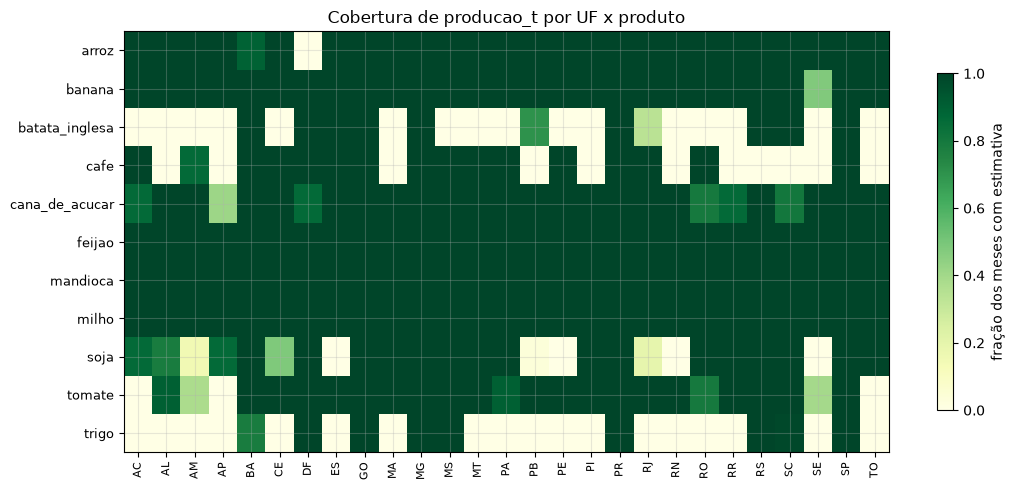

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
mapa = (
    df.assign(tem=df["producao_t"].notna())
    .pivot_table(index="produto", columns="sigla_uf", values="tem", aggfunc="mean")
)
im = ax.imshow(mapa, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(mapa.shape[1]), mapa.columns, fontsize=8, rotation=90)
ax.set_yticks(range(mapa.shape[0]), mapa.index, fontsize=9)
fig.colorbar(im, shrink=0.8, label="fração dos meses com estimativa")
ax.set_title("Cobertura de producao_t por UF x produto")
fig.tight_layout()
plt.show()

---
## 3. Escala e distribuição das medidas

Os produtos vivem em ordens de grandeza muito diferentes — cana-de-açúcar é medida em centenas de
milhões de toneladas, feijão em milhões. Comparar produção entre produtos em valor absoluto não faz
sentido; é mais um argumento para trabalhar com a **variação** e não com o nível.

In [11]:
df[["area_plantada_ha", "area_colhida_ha", "producao_t", "rendimento_kg_ha", "revisao_pct_prod"]].astype(
    "float64"
).describe().T

,count,mean,std,min,25%,50%,75%,max
area_plantada_ha,"35,539.00","333,601.14","1,079,312.19",0.00,"4,572.00","23,531.00","130,382.00","13,073,996.00"
area_colhida_ha,"35,539.00","327,957.98","1,070,674.48",0.00,"4,529.00","21,860.00","124,709.00","13,073,996.00"
producao_t,"35,539.00","4,152,944.44","25,244,518.06",0.00,"21,319.00","168,080.00","921,704.00","415,891,909.00"
rendimento_kg_ha,"35,530.00","17,163.08","22,172.14",0.00,"2,483.81","6,730.70","22,042.00","324,921.00"
revisao_pct_prod,"32,441.00",510.56,"88,527.23",-100.00,0.00,0.00,0.00,"15,938,200.00"


In [12]:
ultimo_2024 = df[(df["ano_safra"] == 2024) & (df["ano_mes"].dt.month == 12)]

escala = ultimo_2024.groupby("produto").agg(
    producao_br_t=("producao_t", "sum"),
    rendimento_mediano_kg_ha=("rendimento_kg_ha", "median"),
    ufs=("producao_t", "count"),
).sort_values("producao_br_t", ascending=False)
escala

,producao_br_t,rendimento_mediano_kg_ha,ufs
produto,,,
cana_de_acucar,706720425,"62,876.00",27
soja,144946662,"3,180.50",22
milho,114703192,"4,635.80",27
mandioca,19059194,"14,526.00",27
arroz,10591604,"3,512.50",26
trigo,7530249,"3,302.00",9
banana,6995034,"13,045.50",26
tomate,4666924,"56,190.00",23
batata_inglesa,4507809,"33,008.40",9


A estimativa final de 2024 dá números plausíveis contra o que se sabe da agricultura brasileira:
soja ~145 Mt, milho ~115 Mt, cana ~707 Mt. Os rendimentos também batem com a ordem de grandeza
esperada — cana perto de 60 t/ha, feijão perto de 0,9 t/ha, café ~1,5 t/ha.

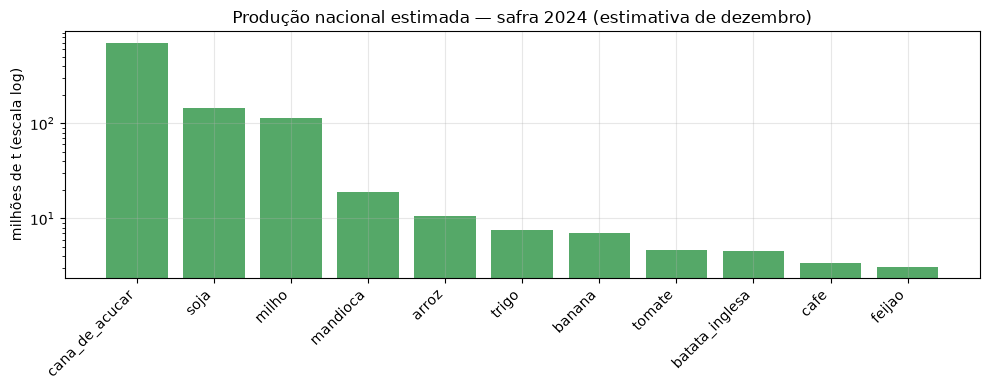

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ordem = escala.index
ax.bar(range(len(ordem)), escala["producao_br_t"] / 1e6, color="#55A868")
ax.set_yscale("log")
ax.set_xticks(range(len(ordem)), ordem, rotation=45, ha="right")
ax.set_ylabel("milhões de t (escala log)")
ax.set_title("Produção nacional estimada — safra 2024 (estimativa de dezembro)")
fig.tight_layout()
plt.show()

---
## 4. A armadilha: cada mês é uma fotografia, não um fluxo

Este é o ponto que decide se o dataset vai ser usado certo ou errado. Vou mostrar a trajetória de
uma safra concreta.

In [14]:
traj = df[(df["produto"] == "soja") & (df["sigla_uf"] == "MT") & (df["ano_safra"] == 2024)]
traj = traj[["ano_mes", "area_plantada_ha", "producao_t", "revisao_pct_prod"]].copy()
traj["ano_mes"] = traj["ano_mes"].dt.strftime("%Y-%m")
traj.set_index("ano_mes")

,area_plantada_ha,producao_t,revisao_pct_prod
ano_mes,,,
2024-01,12097748,39402311,<NA>
2024-02,12097748,39402311,0.00
2024-03,12147858,37943187,-3.70
2024-04,12147858,37943187,0.00
2024-05,12395863,39101841,3.05
2024-06,12395863,39101841,0.00
2024-07,12437432,39265336,0.42
2024-08,12437432,39265336,0.00
2024-09,12439912,39138571,-0.32


Doze linhas, **uma única safra**. A produção oscila em torno de 39 Mt porque o IBGE vai refinando a
estimativa com o andamento da colheita — não porque o MT colhe 39 Mt por mês.

Repare também que a estimativa **só muda em meses alternados**: fev = 0%, mar = -3,7%, abr = 0%,
mai = +3,1%. O LSPA não revisa todo produto todo mês; quando não revisa, repete o valor anterior.

In [15]:
soma_errada = df[(df["produto"] == "soja") & (df["ano_safra"] == 2024)]["producao_t"].sum()
correto = ultimo_2024.loc[ultimo_2024["produto"] == "soja", "producao_t"].sum()

print(f"somando os 12 meses de 2024 : {soma_errada:>18,.0f} t   <- ERRADO")
print(f"estimativa de dezembro/2024 : {correto:>18,.0f} t   <- certo")
print(f"fator de inflação           : {soma_errada / correto:>18.1f}x")

somando os 12 meses de 2024 :      1,757,957,569 t   <- ERRADO
estimativa de dezembro/2024 :        144,946,662 t   <- certo
fator de inflação           :               12.1x


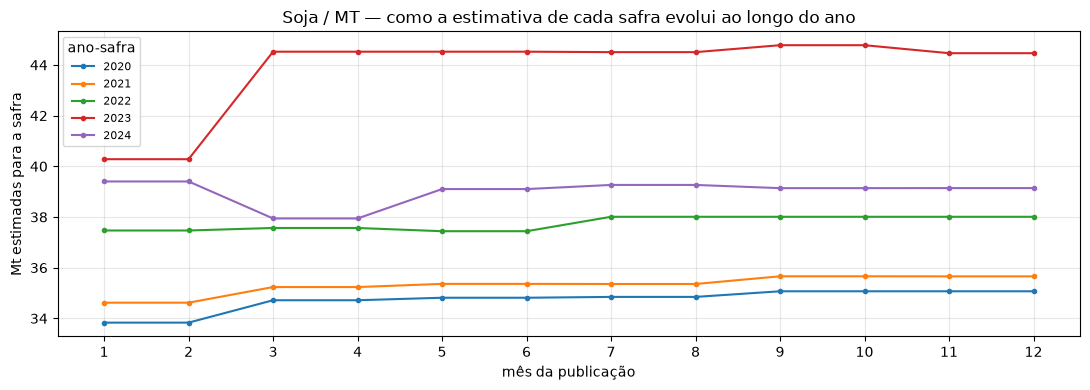

In [16]:
fig, ax = plt.subplots(figsize=(11, 4))
for ano in range(2020, 2025):
    s = df[(df["produto"] == "soja") & (df["sigla_uf"] == "MT") & (df["ano_safra"] == ano)]
    ax.plot(s["ano_mes"].dt.month, s["producao_t"].astype("float64") / 1e6, marker="o", ms=3, label=ano)
ax.set_xticks(range(1, 13))
ax.set_xlabel("mês da publicação")
ax.set_ylabel("Mt estimadas para a safra")
ax.set_title("Soja / MT — como a estimativa de cada safra evolui ao longo do ano")
ax.legend(title="ano-safra", fontsize=8)
fig.tight_layout()
plt.show()

Cada linha é **uma safra**, acompanhada de janeiro a dezembro. As curvas são razoavelmente planas —
o IBGE começa o ano com uma estimativa já próxima do que vai confirmar. É por isso que a revisão
mediana é zero e o sinal interessante está nas caudas.

---
## 5. `revisao_pct_prod` — o sinal de choque de oferta

Esta é a feature que o T-012 existe para produzir. Ela merece atenção porque tem três
particularidades que quebram análise ingênua: nulos por construção, muito zero, e cauda explosiva.

In [17]:
rev = df["revisao_pct_prod"].astype("float64")

print(f"nulos          : {rev.isna().sum():>7,}  ({rev.isna().mean() * 100:.1f}%)")
print(f"exatamente zero: {(rev == 0).sum():>7,}  ({(rev == 0).mean() * 100:.1f}%)")
print(f"não-zero       : {((rev != 0) & rev.notna()).sum():>7,}")

nulos          :  12,406  (27.7%)
exatamente zero:  18,854  (42.0%)
não-zero       :  13,587


In [18]:
por_mes = df.assign(mes=df["ano_mes"].dt.month).groupby("mes")["revisao_pct_prod"].agg(
    n_validos="count",
    pct_zero=lambda s: (s == 0).mean() * 100,
    p95=lambda s: s.quantile(0.95),
)
por_mes.round(2)

,n_validos,pct_zero,p95
mes,,,
1,0,<NA>,<NA>
2,3050,69.18,3.63
3,3050,51.74,10.82
4,3053,59.58,10.16
5,3055,56.04,6.48
6,3055,61.47,4.88
7,3055,53.13,6.89
8,2816,56.07,5.10
9,2818,56.99,4.54


**Janeiro tem zero observações válidas** — e está certo. Janeiro é o primeiro mês do ano-safra, não
existe mês anterior *dentro da mesma safra* com que comparar. O `NaN` é intencional; o script
poderia ter usado dezembro do ano anterior e teria fabricado um salto falso de ±100% todo janeiro.

Os outros nulos são as linhas sem `producao_t` (as lavouras que não existem naquela UF).

In [19]:
nao_zero = rev[(rev != 0) & rev.notna()]

print(nao_zero.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2).to_string())
print(f"\ndentro de -20% a +20%: {((nao_zero >= -20) & (nao_zero <= 20)).mean() * 100:.1f}%")

count       13,587.00
mean         1,219.04
std        136,792.25
min           -100.00
5%             -17.07
25%             -1.91
50%             -0.01
75%              1.38
95%             16.10
max     15,938,200.00

dentro de -20% a +20%: 91.8%


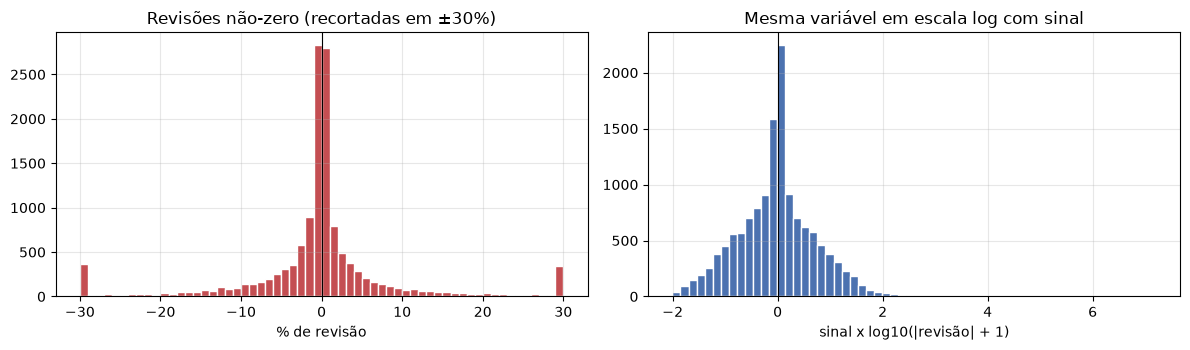

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(nao_zero.clip(-30, 30), bins=60, color="#C44E52", edgecolor="white")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Revisões não-zero (recortadas em ±30%)")
axes[0].set_xlabel("% de revisão")

axes[1].hist(np.sign(nao_zero) * np.log10(nao_zero.abs() + 1), bins=60, color="#4C72B0", edgecolor="white")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Mesma variável em escala log com sinal")
axes[1].set_xlabel("sinal x log10(|revisão| + 1)")
fig.tight_layout()
plt.show()

O grosso é bem comportado: **91,8% das revisões não-zero ficam entre -20% e +20%**, mediana
praticamente em zero, distribuição quase simétrica. Mas a média é 1.219% e o máximo passa de 15
milhões por cento. Vale ver de onde vem.

In [21]:
ordenado = df.sort_values(["sigla_uf", "produto", "ano_mes"]).copy()
ordenado["producao_anterior_t"] = ordenado.groupby(["sigla_uf", "produto", "ano_safra"])["producao_t"].shift()

extremos = ordenado.reindex(ordenado["revisao_pct_prod"].astype("float64").abs().sort_values(ascending=False).index)
extremos = extremos.head(8)[
    ["sigla_uf", "produto", "ano_mes", "producao_anterior_t", "producao_t", "revisao_pct_prod"]
].copy()
extremos["ano_mes"] = extremos["ano_mes"].dt.strftime("%Y-%m")
extremos.reset_index(drop=True)

,sigla_uf,produto,ano_mes,producao_anterior_t,producao_t,revisao_pct_prod
0,RO,cana_de_acucar,2017-02,1,159383,"15,938,200.00"
1,AP,cana_de_acucar,2017-02,1,4480,"447,900.00"
2,RO,tomate,2017-06,1,1233,"123,200.00"
3,RJ,batata_inglesa,2015-11,2,628,"31,300.00"
4,TO,cana_de_acucar,2016-03,28269,1418516,"4,917.92"
5,DF,batata_inglesa,2017-11,379,10812,"2,752.77"
6,RR,feijao,2024-11,549,9165,"1,569.40"
7,PE,milho,2014-02,6120,89442,"1,361.47"


A causa é aritmética, não erro de coleta: a produção do mês anterior era **1 tonelada**. Cana em RO
sai de 1 t para 159.383 t e a variação percentual estoura. É divisão por quase-zero.

In [22]:
grandes = ordenado[ordenado["revisao_pct_prod"].astype("float64").abs() > 100]

print(f"revisões com |valor| > 100%: {len(grandes):,} de {int(rev.notna().sum()):,} ({len(grandes) / rev.notna().sum() * 100:.2f}%)")
print(f"produção anterior mediana nesses casos : {grandes['producao_anterior_t'].median():>12,.0f} t")
print(f"produção anterior mediana no geral     : {ordenado['producao_anterior_t'].median():>12,.0f} t")

revisões com |valor| > 100%: 86 de 32,441 (0.27%)
produção anterior mediana nesses casos :        7,014 t
produção anterior mediana no geral     :      168,055 t


Confirmado: onde a revisão explode, a base é **24 vezes menor** que a típica. São 0,27% das linhas,
todas em lavouras marginais.

Isso não é dado para jogar fora — é dado que precisa de tratamento. As opções razoáveis: recortar
(`clip`) em algo como ±50%, filtrar por produção mínima, ou usar diferença logarítmica em vez de
variação percentual. A escolha é do T-024; o que este notebook estabelece é que **usar
`revisao_pct_prod` crua alimenta o modelo com valores de 7 dígitos**.

In [23]:
rev_produto = (
    df.assign(rev=rev)
    .query("rev != 0")
    .groupby("produto")["rev"]
    .agg(n="count", p05=lambda s: s.quantile(0.05), mediana="median", p95=lambda s: s.quantile(0.95))
    .sort_values("p95", ascending=False)
)
rev_produto.round(2)

,n,p05,mediana,p95
produto,,,,
trigo,477,-23.79,-0.03,43.81
tomate,1161,-16.87,0.04,29.31
batata_inglesa,456,-21.85,0.01,26.66
milho,1853,-23.77,-0.01,17.91
feijao,1782,-26.56,-0.46,17.84
cafe,877,-17.46,-0.01,15.65
arroz,1415,-25.67,-0.15,14.60
banana,1471,-9.08,0.01,10.91
mandioca,1605,-10.67,-0.01,10.68


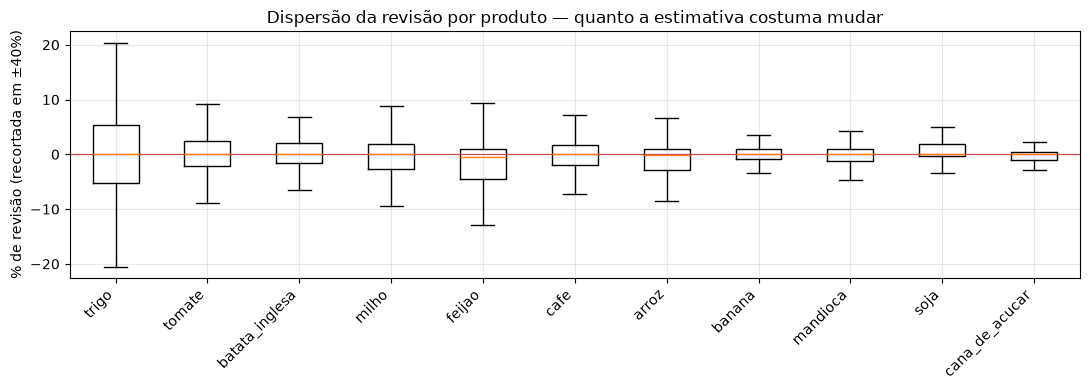

In [24]:
fig, ax = plt.subplots(figsize=(11, 4))
dados = [df.loc[(df["produto"] == p) & (rev != 0) & rev.notna(), "revisao_pct_prod"].astype("float64").clip(-40, 40)
         for p in rev_produto.index]
ax.boxplot(dados, tick_labels=list(rev_produto.index), showfliers=False)
ax.axhline(0, color="#C44E52", lw=0.9)
ax.set_ylabel("% de revisão (recortada em ±40%)")
ax.set_title("Dispersão da revisão por produto — quanto a estimativa costuma mudar")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

Os produtos não são igualmente voláteis. Lavouras concentradas e de ciclo longo (cana, café) têm
revisão apertada; hortaliças e lavouras de ciclo curto espalhadas por muitas UFs pequenas
(tomate, batata) revisam muito mais. Se a revisão vira feature, essa diferença de escala entre
produtos importa.

---
## 6. Área plantada vs. colhida: quebra de safra

A diferença entre o que se plantou e o que se espera colher é outro sinal de choque — quando a
área colhida cai abaixo da plantada, houve perda (seca, geada, praga).

In [25]:
dez = df[(df["ano_mes"].dt.month == 12) & df["producao_t"].notna()].copy()
dez["perda_area_pct"] = (1 - dez["area_colhida_ha"] / dez["area_plantada_ha"].where(dez["area_plantada_ha"] > 0)) * 100

print(dez["perda_area_pct"].astype("float64").describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2).to_string())
print(f"\nlinhas com perda > 5%: {(dez['perda_area_pct'] > 5).sum():,} de {len(dez):,}")

count   2,837.00
mean        4.61
std        10.67
min         0.00
50%         0.05
90%        14.69
95%        27.11
99%        51.78
max        77.50

linhas com perda > 5%: 602 de 2,839


In [26]:
piores = dez.nlargest(10, "perda_area_pct")[
    ["sigla_uf", "produto", "ano_safra", "area_plantada_ha", "area_colhida_ha", "perda_area_pct", "producao_t"]
]
piores.reset_index(drop=True)

,sigla_uf,produto,ano_safra,area_plantada_ha,area_colhida_ha,perda_area_pct,producao_t
0,RN,milho,2016,36976,8321,77.50,3548
1,RN,milho,2015,42915,11253,73.78,4222
2,PE,cafe,2016,2388,650,72.78,374
3,AL,milho,2016,29349,8469,71.14,13810
4,SE,milho,2018,142526,41536,70.86,160984
5,AC,cana_de_acucar,2017,2455,723,70.55,21950
6,AL,feijao,2016,37733,12108,67.91,5964
7,RN,feijao,2015,43712,14233,67.44,4169
8,RJ,arroz,2018,314,104,66.88,376
9,PE,milho,2025,169817,58645,65.47,33219


Na maior parte dos casos área plantada e colhida praticamente coincidem — mediana de 0,05%. Mas a
distribuição tem cauda pesada: **21% das linhas têm perda acima de 5%** e o p99 passa de 50%. Não é
uma variável rara, é uma variável concentrada.

E os piores casos não são aleatórios: **RN, AL, SE e PE em 2015–2016** dominam o topo da lista, com
perdas de 65% a 77% da área. É a seca histórica do Nordeste aparecendo no dado. Isso é encorajador
para o projeto — a variável captura choque climático real, que é exatamente o que o modelo quer
ligar a preço.

In [27]:
perda_ano = (
    dez.assign(perdeu=dez["perda_area_pct"] > 20)
    .groupby("ano_safra")
    .agg(paineis=("perdeu", "size"), com_perda_alta=("perdeu", "sum"))
)
perda_ano["pct"] = (perda_ano["com_perda_alta"] / perda_ano["paineis"] * 100).round(1)
perda_ano

,paineis,com_perda_alta,pct
ano_safra,,,
2014,224,24,10.70
2015,239,31,13.00
2016,240,32,13.30
2017,240,25,10.40
2018,238,27,11.30
2019,237,13,5.50
2020,235,4,1.70
2021,235,9,3.80
2022,237,4,1.70


---
## O que fica para a modelagem

| Ponto | Consequência |
|---|---|
| Cada linha é a **estimativa da safra do ano**, não a produção do mês | Nunca somar meses; para o valor da safra, usar a estimativa do último mês |
| Grid completo (27 × 11 × 151), sem duplicata | A junção do T-024 não precisa temer linha faltando — só valor faltando |
| 53 painéis UF×produto **sem dado nenhum** (trigo em 9 UFs, batata em 11) | Nulo ≠ zero. Imputar zero distorce média ponderada por UF |
| 25 painéis parciais (lavoura marginal, intermitente) | Requer decisão explícita: descartar UF pequena ou aceitar série com buraco |
| `revisao_pct_prod` é `NaN` em **todo janeiro**, por construção | Correto — não há mês anterior na mesma safra. Não "corrigir" |
| 42% das revisões são exatamente **zero** | O LSPA não revisa todo produto todo mês; zero = "não atualizou", não "não mudou nada" |
| Cauda explosiva (máx. 15.938.200%) vinda de base ~1 t | Recortar, filtrar por produção mínima ou usar log-diferença antes de modelar |
| Volatilidade da revisão varia muito por produto | Normalizar por produto se a feature for usada entre produtos |
| Escalas de produção diferem em 2 ordens de grandeza | Trabalhar com variação relativa, não nível absoluto |
| Perda de área (plantada − colhida) marca seca real: NE em 2015–16 | Candidata a feature de choque climático, junto com a revisão |
| `nome_uf` é redundante com `sigla_uf`; `ano_safra` = ano de `ano_mes` | Podem sair do conjunto de features |